##Creating Dataset

In [1]:
import csv
import random

# Define column headers and possible data
columns = ["Name", "Surname", "Gender", "SPOS", "DSBDA", "WT", "DA"]
names = ["Alex", "Jordan", "Taylor", "Morgan", "Casey", "Jamie", "Riley", "Quinn", "Bailey", "Drew"]
surnames = ["Smith", "Johnson", "Brown", "Williams", "Jones", "Garcia", "Miller", "Davis", "Martinez", "Lopez"]
genders = ["Male", "Female"]
marks_range = (40, 100)
outlier_marks_range = (300,400)
missing_values = ["NaN", "na","?","","--"]

def random_mark_or_missing(allow_missing):
    if allow_missing==0:
        return random.choice([random.randint(*marks_range)] + missing_values)
    elif allow_missing==3:
        return random.randint(*outlier_marks_range)
    else:
        return random.randint(*marks_range)

# Create 20 rows with no missing values
rows = []
for i in range(30):
    row = [
        random.choice(names),
        random.choice(surnames),
        random.choice(genders),
        random_mark_or_missing(i%4),  # No missing values
        random_mark_or_missing(i%4),
        random_mark_or_missing(i%4),
        random_mark_or_missing(i%4),
    ]
    rows.append(row)

file_name = "random_students_with_missing.csv"
with open(file_name, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(columns)
    writer.writerows(rows)

print(f"CSV file '{file_name}' with missing values has been created successfully!")

CSV file 'random_students_with_missing.csv' with missing values has been created successfully!


#Describing Dataset

###Loading Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('random_students_with_missing.csv', na_values = missing_values)

###Attributes

In [3]:
df.shape

(30, 7)

In [4]:
df.dtypes

,0
Name,object
Surname,object
Gender,object
SPOS,float64
DSBDA,float64
WT,float64
DA,float64


In [5]:
df.columns

Index(['Name', 'Surname', 'Gender', 'SPOS', 'DSBDA', 'WT', 'DA'], dtype='object')

###Statistical Information About Dataset

In [6]:
df.head()

,Name,Surname,Gender,SPOS,DSBDA,WT,DA
0,Casey,Smith,Male,NaN,NaN,NaN,NaN
1,Riley,Brown,Female,41.0,43.0,65.0,85.0
2,Jordan,Jones,Male,54.0,56.0,97.0,50.0
3,Drew,Jones,Female,354.0,369.0,388.0,392.0
4,Drew,Jones,Male,NaN,NaN,NaN,NaN


In [7]:
df.tail()

,Name,Surname,Gender,SPOS,DSBDA,WT,DA
25,Drew,Jones,Female,47.0,93.0,100.0,90.0
26,Drew,Smith,Male,54.0,42.0,67.0,100.0
27,Morgan,Martinez,Female,384.0,371.0,319.0,394.0
28,Alex,Garcia,Female,NaN,NaN,NaN,63.0
29,Bailey,Martinez,Female,97.0,56.0,92.0,92.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Name     30 non-null     object 
 1   Surname  30 non-null     object 
 2   Gender   30 non-null     object 
 3   SPOS     22 non-null     float64
 4   DSBDA    23 non-null     float64
 5   WT       22 non-null     float64
 6   DA       24 non-null     float64
dtypes: float64(4), object(3)
memory usage: 1.8+ KB


In [9]:
df.describe()

,SPOS,DSBDA,WT,DA
count,22.000000,23.000000,22.000000,24.000000
mean,165.227273,154.521739,164.181818,162.666667
std,133.548611,144.280935,136.264671,142.957174
min,41.000000,40.000000,44.000000,45.000000
25%,75.250000,50.000000,68.000000,66.750000
50%,97.500000,70.000000,87.500000,85.000000
75%,308.500000,343.000000,325.750000,361.500000
max,400.000000,384.000000,388.000000,399.000000


#Scan all variables for missing values and inconsistencies.

###Detecting Null Entries

In [10]:
df.isnull()

,Name,Surname,Gender,SPOS,DSBDA,WT,DA
0,False,False,False,True,True,True,True
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,True,True,True,True
5,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False
8,False,False,False,True,False,True,True
9,False,False,False,False,False,False,False


In [11]:
missing_values = df.isnull().sum()
print("Missing Values Count:\n", missing_values)

Missing Values Count:
 Name       0
Surname    0
Gender     0
SPOS       8
DSBDA      7
WT         8
DA         6
dtype: int64


In [12]:
print("Total Missing Values : ", df.isnull().sum().sum())

Total Missing Values :  29


###Standardizing Missing Values

In [13]:
df.replace(["NaN", "na", "?", "", "--"], pd.NA, inplace=True)

In [14]:
df.head(10)

,Name,Surname,Gender,SPOS,DSBDA,WT,DA
0,Casey,Smith,Male,NaN,NaN,NaN,NaN
1,Riley,Brown,Female,41.0,43.0,65.0,85.0
2,Jordan,Jones,Male,54.0,56.0,97.0,50.0
3,Drew,Jones,Female,354.0,369.0,388.0,392.0
4,Drew,Jones,Male,NaN,NaN,NaN,NaN
5,Drew,Garcia,Female,92.0,100.0,71.0,61.0
6,Taylor,Garcia,Female,96.0,44.0,44.0,75.0
7,Bailey,Davis,Male,320.0,338.0,351.0,399.0
8,Jamie,Davis,Male,NaN,90.0,NaN,NaN
9,Jordan,Jones,Female,98.0,70.0,75.0,45.0


###Handling Missing Values with Mean

In [15]:
df['SPOS'].fillna(df['SPOS'].mean(), inplace=True)
df['DSBDA'].fillna(df['DSBDA'].mean(), inplace=True)
df['WT'].fillna(df['WT'].mean(), inplace=True)
df['DA'].fillna(df['DA'].mean(), inplace=True)

<ipython-input-15-79a5753e9695>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SPOS'].fillna(df['SPOS'].mean(), inplace=True)
<ipython-input-15-79a5753e9695>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [16]:
df.head(10)

,Name,Surname,Gender,SPOS,DSBDA,WT,DA
0,Casey,Smith,Male,165.227273,154.521739,164.181818,162.666667
1,Riley,Brown,Female,41.000000,43.000000,65.000000,85.000000
2,Jordan,Jones,Male,54.000000,56.000000,97.000000,50.000000
3,Drew,Jones,Female,354.000000,369.000000,388.000000,392.000000
4,Drew,Jones,Male,165.227273,154.521739,164.181818,162.666667
5,Drew,Garcia,Female,92.000000,100.000000,71.000000,61.000000
6,Taylor,Garcia,Female,96.000000,44.000000,44.000000,75.000000
7,Bailey,Davis,Male,320.000000,338.000000,351.000000,399.000000
8,Jamie,Davis,Male,165.227273,90.000000,164.181818,162.666667
9,Jordan,Jones,Female,98.000000,70.000000,75.000000,45.000000


In [17]:
df['SPOS'] = df['SPOS'].astype(int)
df['DSBDA'] = df['DSBDA'].astype(int)
df['WT'] = df['WT'].astype(int)
df['DA'] = df['DA'].astype(int)

In [18]:
df.dtypes

,0
Name,object
Surname,object
Gender,object
SPOS,int64
DSBDA,int64
WT,int64
DA,int64


In [19]:
df.head(10)

,Name,Surname,Gender,SPOS,DSBDA,WT,DA
0,Casey,Smith,Male,165,154,164,162
1,Riley,Brown,Female,41,43,65,85
2,Jordan,Jones,Male,54,56,97,50
3,Drew,Jones,Female,354,369,388,392
4,Drew,Jones,Male,165,154,164,162
5,Drew,Garcia,Female,92,100,71,61
6,Taylor,Garcia,Female,96,44,44,75
7,Bailey,Davis,Male,320,338,351,399
8,Jamie,Davis,Male,165,90,164,162
9,Jordan,Jones,Female,98,70,75,45


#Scanning for Outliers

###Detecting Outliers


Outliers detected in each column:
SPOS     7
DSBDA    7
WT       7
DA       7
dtype: int64


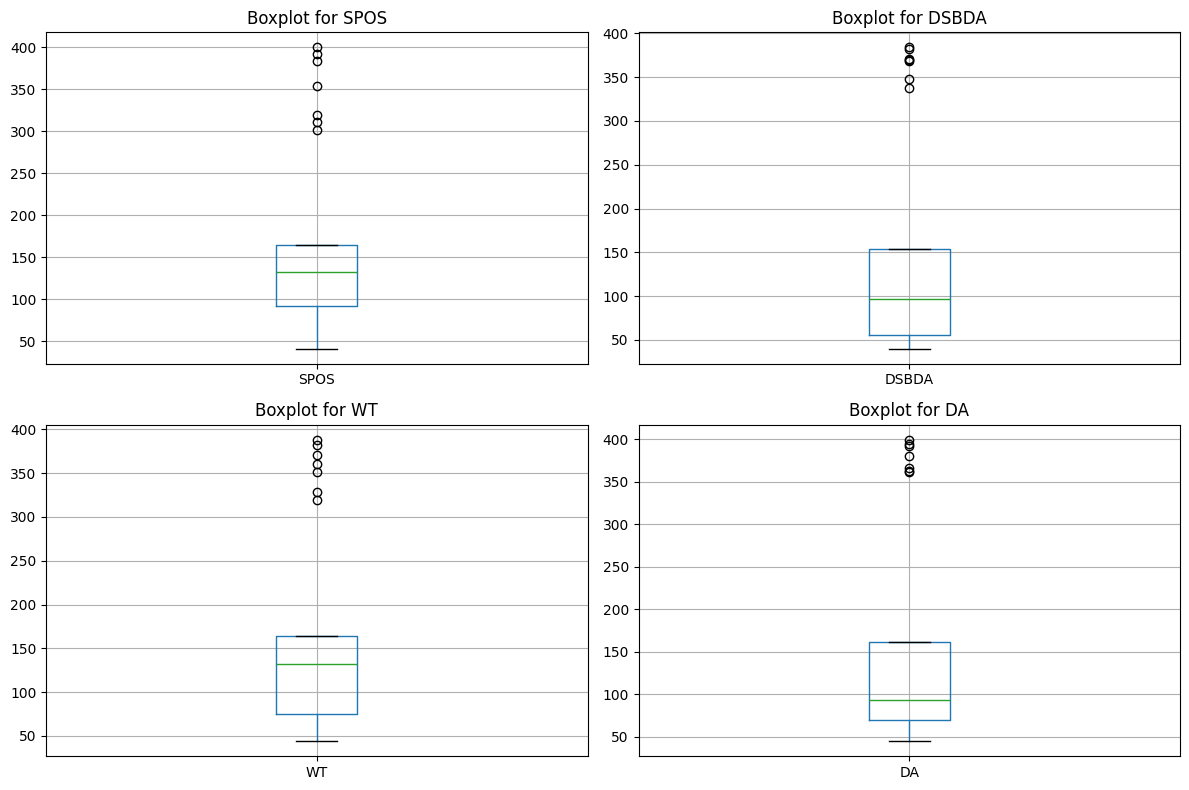

In [20]:
numerical_columns = ['SPOS', 'DSBDA', 'WT', 'DA']  # List of numerical columns

# Step 3: Calculate Q1, Q3 and IQR for outlier detection
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

# Step 4: Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 5: Detect outliers
outliers = (df[numerical_columns] < lower_bound) | (df[numerical_columns] > upper_bound)

# Print out the number of outliers detected in each column
outliers_count = outliers.sum()
print("\nOutliers detected in each column:")
print(outliers_count)

# Step 6: Plot boxplots for each numerical column
plt.figure(figsize=(12, 8))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 2, i)
    df.boxplot(column=column)
    plt.title(f'Boxplot for {column}')

plt.tight_layout()
plt.show()

In [21]:
numeric_cols = ['SPOS', 'DSBDA', 'WT', 'DA']

# Detect and remove outliers using IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
valid_range_min = (Q1 - 1.5 * IQR)
valid_range_max = (Q3 + 1.5 * IQR)

outliers_df = df[((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print(outliers_df)


      Name   Surname  Gender  SPOS  DSBDA   WT   DA
3     Drew     Jones  Female   354    369  388  392
7   Bailey     Davis    Male   320    338  351  399
11  Taylor   Johnson  Female   301    384  382  361
15  Bailey     Brown  Female   400    370  360  363
19    Alex     Brown    Male   392    382  328  366
23  Taylor    Miller  Female   311    348  371  380
27  Morgan  Martinez  Female   384    371  319  394


In [22]:
df.shape

(30, 7)

###Removing Outliers

In [23]:
# Select only numerical columns
numeric_cols = ['SPOS', 'DSBDA', 'WT', 'DA']

# Detect and remove outliers using IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Filtering data
df_cleaned = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original DataFrame shape:", df.shape)
print("Cleaned DataFrame shape:", df_cleaned.shape)


Original DataFrame shape: (30, 7)
Cleaned DataFrame shape: (23, 7)


#Applying Data Transformation

In [24]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt


Final dataset after transformation:
      Name   Surname  Gender  SPOS  DSBDA   WT   DA  DSBDA_Log  WT_Normalized
0    Casey     Smith    Male   165    154  164  162   5.036953       0.348837
1    Riley     Brown  Female    41     43   65   85   3.761200       0.061047
2   Jordan     Jones    Male    54     56   97   50   4.025352       0.154070
3     Drew     Jones  Female   354    369  388  392   5.910797       1.000000
4     Drew     Jones    Male   165    154  164  162   5.036953       0.348837
5     Drew    Garcia  Female    92    100   71   61   4.605170       0.078488
6   Taylor    Garcia  Female    96     44   44   75   3.784190       0.000000
7   Bailey     Davis    Male   320    338  351  399   5.823046       0.892442
8    Jamie     Davis    Male   165     90  164  162   4.499810       0.348837
9   Jordan     Jones  Female    98     70   75   45   4.248495       0.090116
10    Alex    Miller  Female    85     88   56   46   4.477337       0.034884
11  Taylor   Johnson  Femal

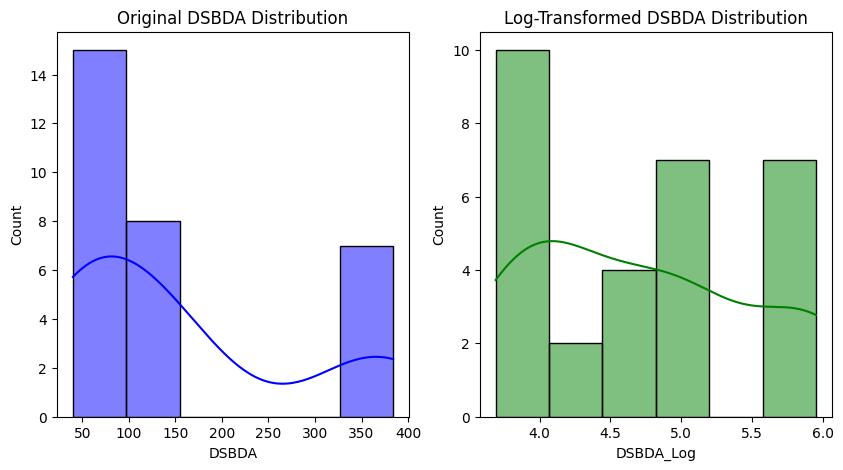

In [25]:
df["DSBDA_Log"] = np.log(df["DSBDA"])

# Optional: Normalize the "WT" column for better scale
scaler = MinMaxScaler()
df["WT_Normalized"] = scaler.fit_transform(df[["WT"]])

# Print the final dataset
print("\nFinal dataset after transformation:")
print(df)

# Visualization of transformed variable
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df["DSBDA"], kde=True, color="blue")
plt.title("Original DSBDA Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df["DSBDA_Log"], kde=True, color="green")
plt.title("Log-Transformed DSBDA Distribution")
plt.show()